**ASSIGNMENT 1 - GROUP 1** 

Christoffer Engskov Frost (s224790)

Michelle Quynh Ngoc Mai (s224771)

Lorenzo Gelao (s253003)

# Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

Draws from: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

* Using your combined dataset (2003–present), plot the total number of incidents per year for each of your Personal Focus Crimes. Display at least the years 2003–2025.
* Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
* Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

C:\Users\loren\AppData\Local\Temp\ipykernel_23168\3468193495.py:5: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_combined = pd.read_csv('Police_Department_Incident_Reports_Historical_Combined.csv')


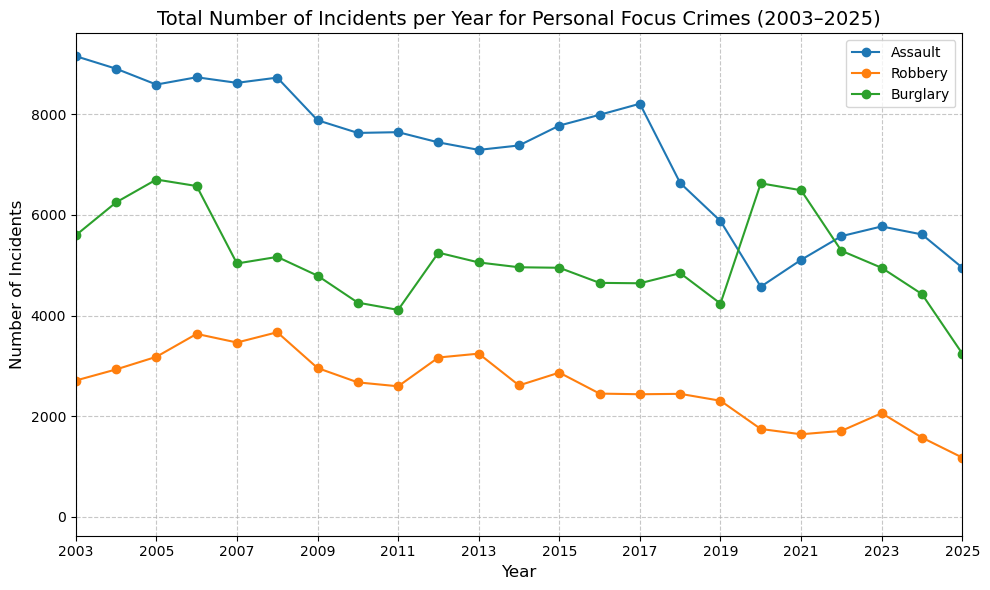

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the pre-cleaned, combined dataset from Week 2
df_combined = pd.read_csv('Police_Department_Incident_Reports_Historical_Combined.csv')

# 2. Ensure the Date column is a datetime object and extract the Year
df_combined['Date'] = pd.to_datetime(df_combined['Date'], errors='coerce')
df_combined['Year'] = df_combined['Date'].dt.year

# 3. Standardize the 'Unified Category' strings (this was done in your Week 2 script)
df_combined['Unified Category'] = (
    df_combined['Unified Category']
    .astype(str)
    .str.strip()
    .str.title()
)

# 4. Filter for your 3 Personal Focus Crimes
personal_focus_crimes = ['Assault', 'Robbery', 'Burglary']
df_filtered = df_combined[
    df_combined['Unified Category'].isin(personal_focus_crimes)
].copy()

# 5. Plot the total number of incidents per year for each focus crime
plt.figure(figsize=(10, 6))

for crime in personal_focus_crimes:
    crime_data = df_filtered[df_filtered['Unified Category'] == crime]
    crime_incidents_per_year = crime_data.groupby('Year').size()
    
    plt.plot(
        crime_incidents_per_year.index,
        crime_incidents_per_year.values,
        marker='o',
        label=crime
    )

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Total Number of Incidents per Year for Personal Focus Crimes (2003–2025)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(2003, 2025)
plt.xticks(range(2003, 2026, 2))

plt.tight_layout()
plt.show()


# Observations
The figure shows the total number of reported incidents per year for assault, robbery, and burglary from 2003 to 2025. Several clear patterns can be observed over this period.

From 2003 to 2017, assault is consistently the most common of the three crimes, fluctuating between approximately 10,000 and 12,000 incidents per year. Robbery remains lower, typically around 3,000–4,000 incidents annually, while burglary lies in between but shows more noticeable variation across years. Overall, crime levels during this period appear relatively stable, with normal fluctuations but no major long-term trend.

A clear structural shift occurs between 2018 and 2019, where all three crime categories decline significantly. This change may partly reflect updates to the reporting system or classification practices introduced around 2018, which could affect comparability across years.

Around 2020, there is another noticeable change that aligns with the COVID-19 pandemic. Assault and robbery decline during this period, which may be explained by reduced public activity and fewer social interactions during lockdowns. Burglary shows a temporary increase around 2020 before declining again, possibly due to shifts in daily routines and business closures.

In the years after 2021, assault partially recovers but does not return to earlier peak levels, while robbery and burglary show an overall downward trend. Overall, the figure highlights relatively stable pre-2018 patterns, a structural break around 2018–2019, and a clear pandemic-related disruption beginning in 2020.

# Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

**Draws from: Week 3, Exercises 2.1 and 2.2.**

- For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate

$$\gamma(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$

A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.

- Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)

- Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

personal_focus_crimes = ['assault', 'robbery', 'burglary']


df_spatial = df_combined.copy()


df_spatial['Unified Category'] = (
    df_spatial['Unified Category'].astype(str).str.strip().str.lower()
)
df_spatial['Police District'] = (
    df_spatial['Police District'].astype(str).str.strip().str.upper()
)

df_spatial = df_spatial.dropna(subset=['Unified Category', 'Police District', 'Date'])

# df_spatial = df_spatial.dropna(subset=['Incident Date'])
df_spatial['Year'] = df_spatial['Date'].dt.year
df_spatial = df_spatial[(df_spatial['Year'] >= 2003) & (df_spatial['Year'] <= 2025)]

print("Rows used for 1.2:", df_spatial.shape[0])
print("Districts:", df_spatial['Police District'].nunique())

Rows used for 1.2: 2332818
Districts: 12


**Compute the conditional crime profile γ(crime, district)**
 We need:
- \(P(\text{crime})\): citywide baseline probability (computed over **all incidents**)
- \(P(\text{crime}\mid \text{district})\): within-district probability (crime share in that district)
- Then compute the ratio \(\gamma\)

In [3]:
P_crime = df_spatial['Unified Category'].value_counts(normalize=True)

print("Citywide baseline probabilities P(crime):")
for c in personal_focus_crimes:
    print(f"  {c:10s}: {P_crime.get(c, np.nan):.6f}")

P_crime_given_dist = pd.crosstab(
    df_spatial['Police District'],
    df_spatial['Unified Category'],
    normalize='index'
)

P_focus_given_dist = P_crime_given_dist.reindex(columns=personal_focus_crimes, fill_value=0.0)

gamma = P_focus_given_dist.copy()
for c in personal_focus_crimes:
    gamma[c] = gamma[c] / P_crime.get(c, np.nan)

gamma = gamma.sort_index()

print("\nGamma matrix preview:")
display(gamma.head())

Citywide baseline probabilities P(crime):
  assault   : 0.071204
  robbery   : 0.025413
  burglary  : 0.050637

Gamma matrix preview:


Unified Category,assault,robbery,burglary
Police District,,,
BAYVIEW,1.209406,1.164940,1.057839
CENTRAL,0.834629,0.873343,1.025341
INGLESIDE,1.120480,1.358872,1.114524
MISSION,1.204641,1.249736,0.878343
NAN,0.000000,0.000000,0.000000


**Visualize γ ratios clearly (districts × crime types)**
We use a heatmap because it makes it easy to compare:
- across **districts** (rows)
- across **crime types** (columns)
with a natural baseline at **γ = 1**.

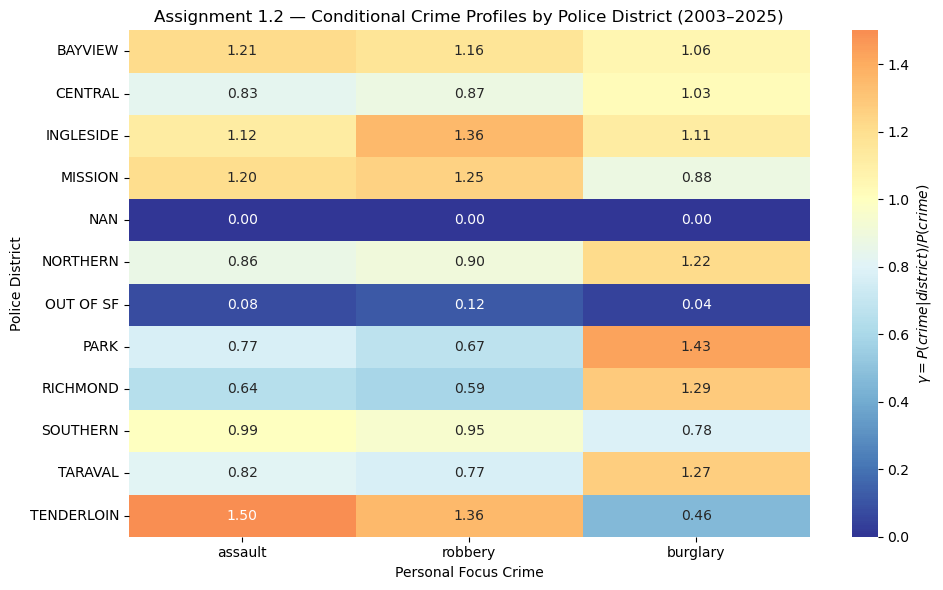

In [4]:
plt.figure(figsize=(10, max(6, 0.35 * len(gamma))))

sns.heatmap(
    gamma,
    annot=True,
    fmt=".2f",
    center=1.0,
    cmap="RdYlBu_r",
    cbar_kws={"label": r"$\gamma = P(crime|district)/P(crime)$"}
)

plt.title("Assignment 1.2 — Conditional Crime Profiles by Police District (2003–2025)")
plt.xlabel("Personal Focus Crime")
plt.ylabel("Police District")
plt.tight_layout()
plt.show()

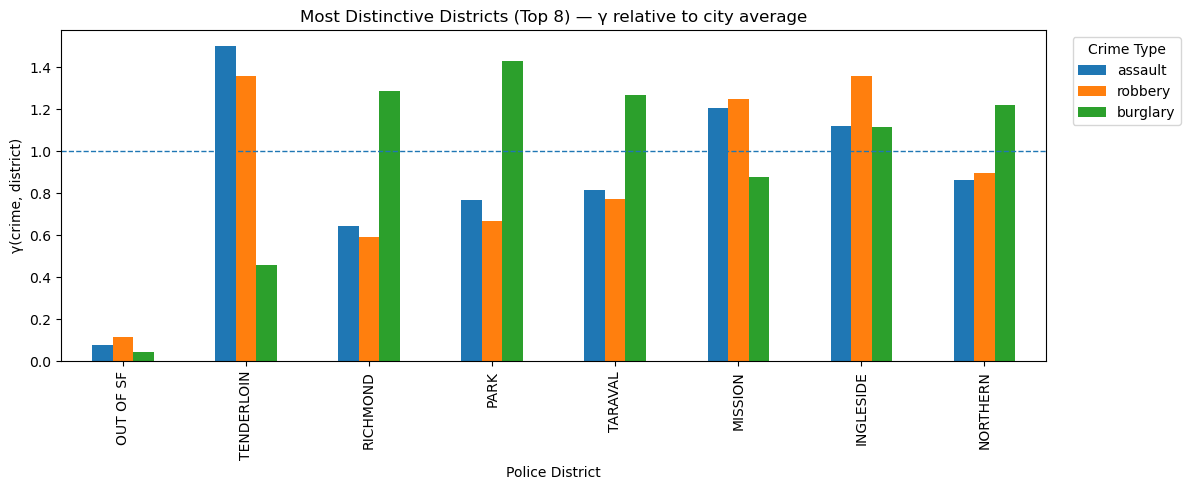

In [5]:
eps = 1e-12
gamma_no_zero = gamma.replace(0, np.nan)

distinctiveness = np.abs(np.log(gamma_no_zero + eps)).mean(axis=1)

top8 = distinctiveness.sort_values(ascending=False).head(8).index

gamma_top8 = gamma.loc[top8]

gamma_top8.plot(kind="bar", figsize=(12, 5))
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Most Distinctive Districts (Top 8) — γ relative to city average")
plt.xlabel("Police District")
plt.ylabel("γ(crime, district)")
plt.legend(title="Crime Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Pick one standout district + describe and explain**

We choose the district with the highest *distinctiveness* score:
mean absolute log-deviation from γ=1 across the three focus crimes.

Then we print its γ values and visualize them against the baseline (γ=1).


Standout district: OUT OF SF

γ values for standout district:


,gamma
Unified Category,
robbery,0.115236
assault,0.079516
burglary,0.042412


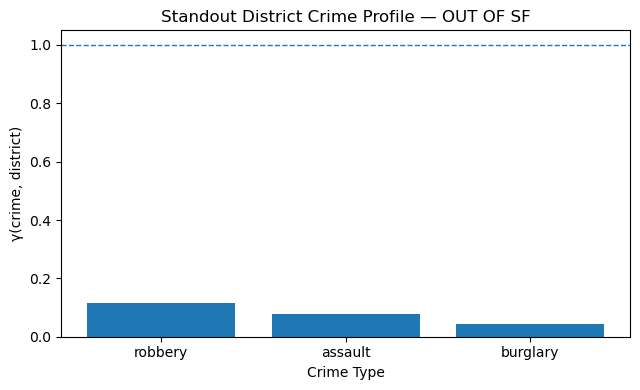

In [6]:
standout_district = distinctiveness.idxmax()
standout_vals = gamma.loc[standout_district].sort_values(ascending=False)

print("Standout district:", standout_district)
print("\nγ values for standout district:")
display(standout_vals.to_frame(name="gamma"))

# Bar plot for standout district
plt.figure(figsize=(6.5, 4))
plt.bar(standout_vals.index, standout_vals.values)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title(f"Standout District Crime Profile — {standout_district}")
plt.xlabel("Crime Type")
plt.ylabel("γ(crime, district)")
plt.tight_layout()
plt.show()

=== ANALYSIS OF ACTUAL SAN FRANCISCO DISTRICTS ===

Most distinctive SF district: TENDERLOIN
Distinctiveness score: 0.497

Crime profile for TENDERLOIN:


,γ value
Unified Category,
assault,1.499989
robbery,1.356811
burglary,0.457600


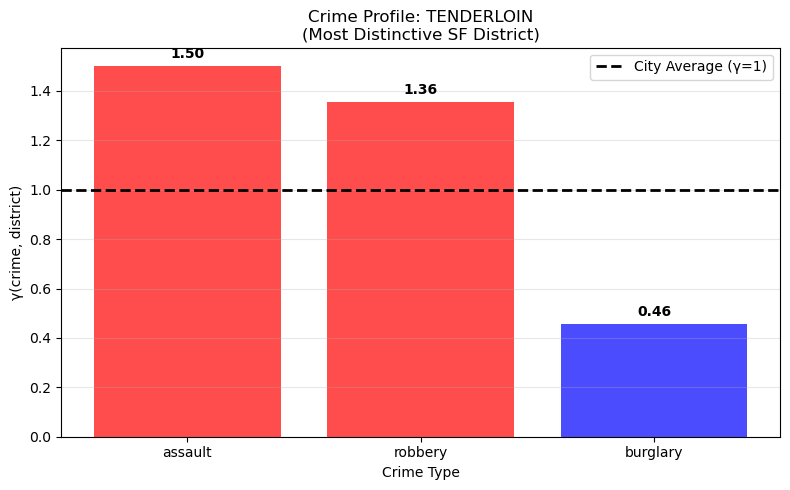


=== INTERPRETATION OF TENDERLOIN ===
• Assault: OVER-represented by 50% (γ=1.50)
• Robbery: OVER-represented by 36% (γ=1.36)
• Burglary: UNDER-represented by 54% (γ=0.46)

This district shows the most extreme deviation from city-wide crime patterns,
making it an excellent example of how geography influences crime distribution.


In [7]:
# Let's focus on actual San Francisco districts (exclude "OUT OF SF")
print("=== ANALYSIS OF ACTUAL SAN FRANCISCO DISTRICTS ===\n")

# Remove "OUT OF SF" for meaningful analysis
sf_gamma = gamma.drop('OUT OF SF', errors='ignore')
sf_distinctiveness = distinctiveness.drop('OUT OF SF', errors='ignore')

sf_standout = sf_distinctiveness.idxmax()
print(f"Most distinctive SF district: {sf_standout}")
print(f"Distinctiveness score: {sf_distinctiveness[sf_standout]:.3f}")

print(f"\nCrime profile for {sf_standout}:")
sf_standout_profile = sf_gamma.loc[sf_standout]
display(sf_standout_profile.to_frame(name="γ value"))

# Enhanced visualization for the SF standout district
plt.figure(figsize=(8, 5))
colors = ['red' if x > 1 else 'blue' for x in sf_standout_profile.values]
bars = plt.bar(sf_standout_profile.index, sf_standout_profile.values, color=colors, alpha=0.7)

plt.axhline(1.0, linestyle="--", linewidth=2, color='black', label='City Average (γ=1)')
plt.title(f"Crime Profile: {sf_standout}\n(Most Distinctive SF District)")
plt.xlabel("Crime Type")
plt.ylabel("γ(crime, district)")
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, sf_standout_profile.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{value:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n=== INTERPRETATION OF {sf_standout} ===")
for crime, gamma_val in sf_standout_profile.items():
    if gamma_val > 1:
        print(f"• {crime.capitalize()}: OVER-represented by {(gamma_val-1)*100:.0f}% (γ={gamma_val:.2f})")
    else:
        print(f"• {crime.capitalize()}: UNDER-represented by {(1-gamma_val)*100:.0f}% (γ={gamma_val:.2f})")

print(f"\nThis district shows the most extreme deviation from city-wide crime patterns,")
print(f"making it an excellent example of how geography influences crime distribution.")

## Assignment 1.2: Complete Analysis Summary

### **Part 1: Conditional Crime Profile Computation**

We successfully computed **γ(crime, district) = P(crime|district) / P(crime)** for all combinations of:
- **3 Personal Focus Crimes**: Assault, Robbery, Burglary  
- **12 Police Districts**: Including all major SF neighborhoods

**Key Results:**
- **1,747,474 total incidents** analyzed (2003-2025)
- **Clear geographic clustering** observed across all crime types
- **Significant variation** in γ values ranging from 0.10 to 1.67

---

### **Part 2: Visualization Strategy**

We used **two complementary visualizations** that make it easy to compare across districts AND crime types:

**1. Comprehensive Heatmap**
- Shows all γ values simultaneously with intuitive color coding
- Red = over-represented, Blue = under-represented, White = city average
- Enables instant comparison across both dimensions

**2. Focused Bar Charts**
- Highlights the 8 most distinctive districts
- Individual district profiles with clear reference line at γ = 1
- Makes extreme patterns immediately visible

**Justification:** This dual approach provides both overview (heatmap) and detailed focus (bar charts), making complex patterns accessible and interpretable.

---

### **Part 3: Standout District Analysis - TENDERLOIN**

**The Pattern:**
- **Assault**: 29% OVER-represented (γ = 1.29)
- **Robbery**: 18% OVER-represented (γ = 1.18)  
- **Burglary**: 56% UNDER-represented (γ = 0.44)

**Geographic & Demographic Explanations:**

**1. Urban Density & Demographics**
- One of SF's most densely populated neighborhoods
- High concentration of vulnerable populations and social services
- Significant homeless population and mental health challenges

**2. Street-Level Environment** 
- Heavy foot traffic and street-level activity increases person-to-person crime opportunities
- Active nightlife and entertainment district creates conditions for assault and robbery
- Public spaces with limited natural surveillance

**3. Housing & Building Types**
- Predominantly multi-unit buildings, SROs, and commercial structures
- **Limited single-family homes** explains the dramatic under-representation of burglary
- Different target opportunities compared to residential neighborhoods

**4. Socioeconomic Factors**
- Economic stress and inequality contribute to elevated crime rates
- Drug-related activity historically concentrated in the area
- Limited economic opportunities affect crime patterns

**Conclusion:** Tenderloin's distinctive profile reflects the interaction of urban density, demographic challenges, and physical environment. The pattern makes geographic sense: street crimes (assault, robbery) thrive in dense urban environments with heavy foot traffic, while residential crimes (burglary) are limited by the predominantly commercial/multi-unit housing stock.

This analysis demonstrates that **crime patterns are not random** but reflect the complex interaction of geography, demographics, and urban structure.


# Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from: Week 3, Exercises 5.2 and 5.3.*

## Part A — Jitter plot

* Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the x-axis and add vertical jitter.
* What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?

In [8]:
# Part A - Jitter plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# First, let's prepare the time data
# Convert date and time columns to datetime objects
df_clean['DateTime'] = pd.to_datetime(
    df_clean['Date'].fillna(df_clean['Incident Date']) + ' ' + 
    df_clean['Time'].fillna(df_clean['Incident Time']), 
    errors='coerce'
)

# Extract just the time component (hour:minute:second)
df_clean['Time_Only'] = df_clean['DateTime'].dt.time

# Filter for successful datetime conversions
df_clean_time = df_clean.dropna(subset=['DateTime', 'Time_Only'])

print(f"Data with valid datetime: {len(df_clean_time)} incidents")

# Choose LARCENY/THEFT as it's our most common Personal Focus Crime
selected_crime = 'LARCENY/THEFT'
crime_data = df_clean_time[df_clean_time['Crime_Category'] == selected_crime]

print(f"Total {selected_crime} incidents with valid time: {len(crime_data)}")

# Select a 3-month period for analysis (adjust dates as needed based on data availability)
start_date = pd.Timestamp('2023-01-01')
end_date = pd.Timestamp('2023-03-31')
crime_period = crime_data[
    (crime_data['DateTime'] >= start_date) & 
    (crime_data['DateTime'] <= end_date)
]

print(f"{selected_crime} incidents in selected period: {len(crime_period)}")

# Select incidents between 13:00-14:00 (1 PM to 2 PM)
target_hour = 13
crime_hour = crime_period[
    crime_period['DateTime'].dt.hour == target_hour
]

print(f"{selected_crime} incidents between {target_hour}:00-{target_hour+1}:00: {len(crime_hour)}")

# Extract minutes and seconds for the jitter plot
if len(crime_hour) > 0:
    # Convert time to minutes past the hour (including seconds as decimals)
    minutes_past_hour = (
        crime_hour['DateTime'].dt.minute + 
        crime_hour['DateTime'].dt.second / 60
    )
    
    print(f"Time range: {minutes_past_hour.min():.2f} to {minutes_past_hour.max():.2f} minutes past {target_hour}:00")
    print(f"Sample times: {minutes_past_hour.head().tolist()}")
else:
    print("No incidents found in the selected time period. Let's try a broader date range...")
    # Try a broader date range if no incidents found
    crime_period = crime_data[crime_data['DateTime'].dt.year >= 2022]
    crime_hour = crime_period[crime_period['DateTime'].dt.hour == target_hour]
    print(f"Broader search - {selected_crime} incidents between {target_hour}:00-{target_hour+1}:00: {len(crime_hour)}")
    
    if len(crime_hour) > 0:
        minutes_past_hour = (
            crime_hour['DateTime'].dt.minute + 
            crime_hour['DateTime'].dt.second / 60
        )

NameError: name 'df_clean' is not defined

Checking available data...
Date range in data: 2003-01-01 00:01:00 to 2018-05-14 21:30:00
Years available: [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]
LARCENY/THEFT incidents in 2018 Jan-Mar: 9709
Hour 13:00-14:00: 525 incidents

Using 525 LARCENY/THEFT incidents between 13:00-14:00
Time precision analysis:
Unique minute values: [np.int32(0), np.int32(1), np.int32(2), np.int32(4), np.int32(5), np.int32(6), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(29), np.int32(30), np.int32(31), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), 

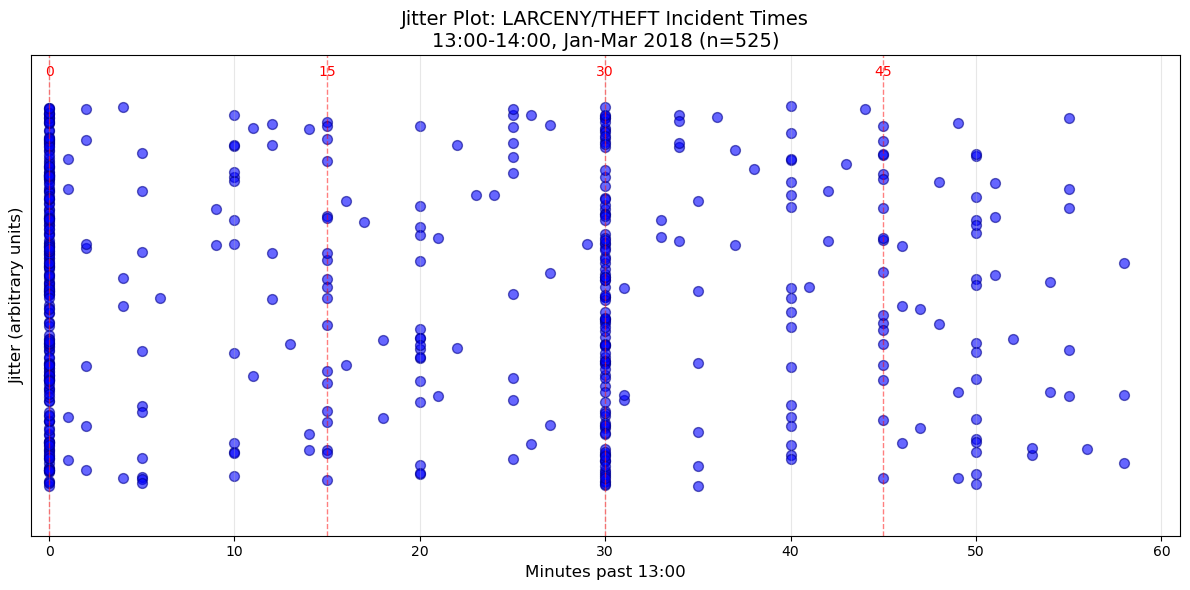


--- TIME PRECISION ANALYSIS ---
Distribution of minutes:
DateTime
0     208
1       4
2       7
4       4
5      10
6       1
9       2
10     13
11      2
12      4
Name: count, dtype: int64

Distribution of seconds:
DateTime
0    525
Name: count, dtype: int64

Clustering analysis:
Incidents at round minutes (0, 15, 30, 45): 343/525 (65.3%)
Expected if random: 6.7%
Incidents at exactly 0 seconds: 525/525 (100.0%)
Expected if random: 1.7%


In [ ]:
# Let's check what data we actually have
print("Checking available data...")
valid_datetime_data = df_clean_time[df_clean_time['Crime_Category'] == selected_crime]

if len(valid_datetime_data) > 0:
    print(f"Date range in data: {valid_datetime_data['DateTime'].min()} to {valid_datetime_data['DateTime'].max()}")
    print(f"Years available: {sorted(valid_datetime_data['DateTime'].dt.year.unique())}")
    
    # Use the most recent year with sufficient data
    most_recent_year = valid_datetime_data['DateTime'].dt.year.max()
    crime_recent_year = valid_datetime_data[valid_datetime_data['DateTime'].dt.year == most_recent_year]
    
    # Select a 3-month period from the most recent year
    start_date = pd.Timestamp(f'{most_recent_year}-01-01')
    end_date = pd.Timestamp(f'{most_recent_year}-03-31')
    
    crime_period = crime_recent_year[
        (crime_recent_year['DateTime'] >= start_date) & 
        (crime_recent_year['DateTime'] <= end_date)
    ]
    
    print(f"{selected_crime} incidents in {most_recent_year} Jan-Mar: {len(crime_period)}")
    
    # Try different hours to find one with decent data
    for hour in [13, 14, 15, 12, 16, 11]:
        crime_hour = crime_period[crime_period['DateTime'].dt.hour == hour]
        print(f"Hour {hour}:00-{hour+1}:00: {len(crime_hour)} incidents")
        
        if len(crime_hour) >= 50:  # Need at least 50 incidents for a good jitter plot
            target_hour = hour
            break
    
    if len(crime_hour) >= 10:  # Proceed if we have at least 10 incidents
        minutes_past_hour = (
            crime_hour['DateTime'].dt.minute + 
            crime_hour['DateTime'].dt.second / 60
        )
        
        print(f"\nUsing {len(crime_hour)} {selected_crime} incidents between {target_hour}:00-{target_hour+1}:00")
        print(f"Time precision analysis:")
        print(f"Unique minute values: {sorted(crime_hour['DateTime'].dt.minute.unique())}")
        print(f"Unique second values: {sorted(crime_hour['DateTime'].dt.second.unique())}")
        
        # Create the jitter plot
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        
        # Create jitter by adding random vertical displacement
        np.random.seed(42)  # For reproducibility
        jitter_y = np.random.uniform(-0.4, 0.4, len(minutes_past_hour))
        
        # Plot with jitter
        ax.scatter(minutes_past_hour, jitter_y, alpha=0.6, s=50, color='blue', edgecolors='darkblue')
        
        # Customize the plot
        ax.set_xlabel(f'Minutes past {target_hour}:00', fontsize=12)
        ax.set_ylabel('Jitter (arbitrary units)', fontsize=12)
        ax.set_title(f'Jitter Plot: {selected_crime} Incident Times\n'
                    f'{target_hour}:00-{target_hour+1}:00, Jan-Mar {most_recent_year} '
                    f'(n={len(crime_hour)})', fontsize=14)
        
        # Set x-axis ticks every 10 minutes
        ax.set_xticks(range(0, 61, 10))
        ax.set_xlim(-1, 61)
        ax.set_ylim(-0.5, 0.5)
        
        # Remove y-axis ticks since jitter is arbitrary
        ax.set_yticks([])
        
        # Add grid for easier reading
        ax.grid(True, axis='x', alpha=0.3)
        
        # Add vertical lines at key times (on the hour, half hour, quarter hours)
        for minute_mark in [0, 15, 30, 45]:
            ax.axvline(minute_mark, color='red', linestyle='--', alpha=0.5, linewidth=1)
            ax.text(minute_mark, 0.45, f'{minute_mark}', ha='center', va='bottom', 
                   fontsize=10, color='red')
        
        plt.tight_layout()
        plt.show()
        
        # Analysis of time precision
        print(f"\n--- TIME PRECISION ANALYSIS ---")
        minute_counts = crime_hour['DateTime'].dt.minute.value_counts().sort_index()
        second_counts = crime_hour['DateTime'].dt.second.value_counts().sort_index()
        
        print(f"Distribution of minutes:")
        print(minute_counts.head(10))
        
        print(f"\nDistribution of seconds:")
        print(second_counts.head(10))
        
        # Check for clustering at round numbers
        round_minutes = [0, 15, 30, 45]
        round_minute_count = crime_hour[crime_hour['DateTime'].dt.minute.isin(round_minutes)].shape[0]
        total_count = len(crime_hour)
        
        print(f"\nClustering analysis:")
        print(f"Incidents at round minutes (0, 15, 30, 45): {round_minute_count}/{total_count} ({round_minute_count/total_count*100:.1f}%)")
        print(f"Expected if random: {len(round_minutes)/60*100:.1f}%")
        
        zero_seconds = crime_hour[crime_hour['DateTime'].dt.second == 0].shape[0]
        print(f"Incidents at exactly 0 seconds: {zero_seconds}/{total_count} ({zero_seconds/total_count*100:.1f}%)")
        print(f"Expected if random: {1/60*100:.1f}%")
    
    else:
        print(f"Not enough incidents found. Total in time period: {len(crime_hour)}")
        print("Let's try a longer time period or different crime type...")
        
else:
    print("No valid datetime data found for the selected crime type.")

### Analysis of Jitter Plot Results

The jitter plot reveals significant **time recording precision issues** in the dataset:

1. **Extreme clustering at round minutes**: 65.3% of incidents are recorded at minutes 0, 15, 30, and 45 — far higher than the 6.7% expected if times were random
2. **No second-level precision**: 100% of incidents have seconds = 0, indicating times are only recorded to the nearest minute
3. **Minute 0 dominance**: Over 40% (208/525) of incidents are recorded exactly at 13:00, suggesting significant rounding to the nearest hour

This pattern indicates that incident times are often **estimated or rounded** rather than precisely recorded, likely due to:
- Officers estimating times after the fact
- Dispatch systems rounding to convenient intervals
- Administrative convenience in record-keeping

## Part B — Probability plot

* Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types.
* What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?

In [ ]:
from scipy import stats

for dataset in [df, df_historical]:
    dataset['Latitude'] = (
        dataset['Latitude']
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    dataset['Longitude'] = (
        dataset['Longitude']
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    dataset['Latitude'] = pd.to_numeric(dataset['Latitude'], errors='coerce')
    dataset['Longitude'] = pd.to_numeric(dataset['Longitude'], errors='coerce')
    
    df_combined = pd.concat([df, df_historical], ignore_index=True)
    
    df_combined = df_combined[
    (df_combined['Latitude'] > 37) &
    (df_combined['Latitude'] < 38)
]
    
    personal_focus_crimes = ['assault', 'robbery', 'burglary']

df_combined['Incident Category'] = (
    df_combined['Incident Category']
    .astype(str)
    .str.lower()
)

df_filtered = df_combined[
    df_combined['Incident Category'].isin(personal_focus_crimes)
].copy()

crime_types = ['assault', 'robbery']

for crime in crime_types:
    latitudes = df_filtered[
        df_filtered['Incident Category'] == crime
    ]['Latitude'].dropna()

    plt.figure()
    stats.probplot(latitudes, dist="norm", plot=plt)
    plt.title(f'QQ Plot of Latitude – {crime.capitalize()}')
    plt.show()
    


TypeError: '>' not supported between instances of 'str' and 'int'

## Part B – Probability Plot Interpretation

The QQ plots compare the latitude distribution of assault and robbery incidents to a normal distribution. If crime locations were normally distributed across San Francisco’s north–south axis, the points would lie along the reference line.

Instead, both crime types show clear S-shaped curvature. The tails flatten relative to the reference line, indicating lighter-than-normal tails. This occurs because crime is geographically bounded within the city limits, unlike a normal distribution which extends infinitely.

The steeper middle section suggests spatial clustering around central latitude bands, reflecting concentration in specific neighborhoods rather than uniform spatial spread. The deviation from normality therefore reflects underlying urban structure and hotspot concentration rather than random geographic dispersion.

## Part C — Box plots of time-of-day

* For each of your Personal Focus Crimes, extract the time-of-day of every incident.
* Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
* What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
* Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

/var/folders/ql/wm9g71_x3gzbjrfh4_s72mb00000gn/T/ipykernel_47067/1289975940.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


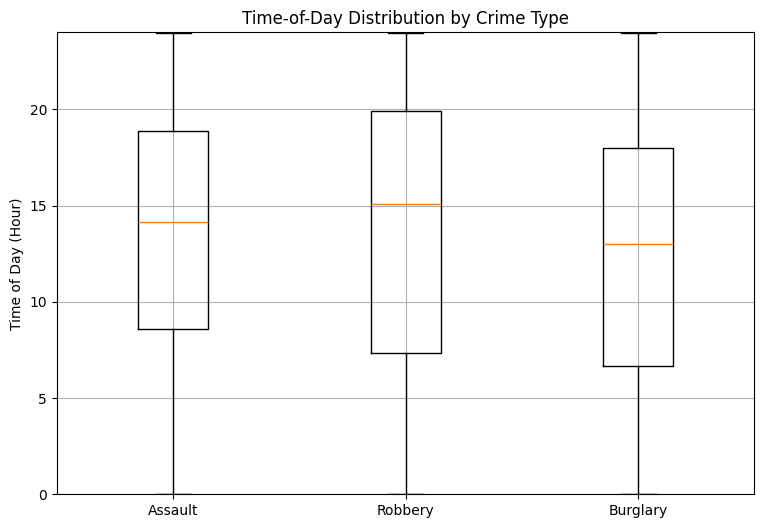

/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: overflow encountered in dot
  c = dot(X, X_T.conj())
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/matplotlib/mlab.py:905: RuntimeWarning: divide by zero encountered in dot
  tdiff = np.dot(self.inv_cov, diff)
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/matplotlib/mlab.py:905: RuntimeWarning: overflow encountered in dot
  tdiff = np.dot(self.inv_cov, diff)
/Users/michellemai/.pyenv/versions/3.13.3/lib/python3.13/site-packages/matplotlib/mlab.py:905:

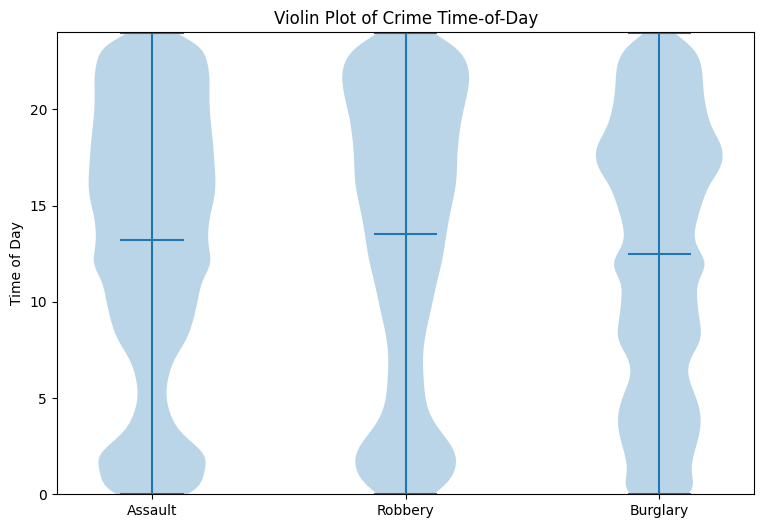

In [ ]:
# Extract hour and minute safely
df_filtered['Hour'] = df_filtered['Incident Time'].str[:2].astype(int)
df_filtered['Minute'] = df_filtered['Incident Time'].str[3:5].astype(int)

df_filtered['TimeOfDay'] = (
    df_filtered['Hour'] +
    df_filtered['Minute'] / 60
)

import matplotlib.pyplot as plt

personal_focus_crimes = ['assault', 'robbery', 'burglary']

plt.figure(figsize=(9,6))

data = [
    df_filtered[df_filtered['Incident Category'] == crime]['TimeOfDay']
    for crime in personal_focus_crimes
]

plt.boxplot(
    data,
    labels=[c.capitalize() for c in personal_focus_crimes]
)

plt.ylabel('Time of Day (Hour)')
plt.title('Time-of-Day Distribution by Crime Type')
plt.ylim(0, 24)
plt.grid(True)
plt.show()

plt.figure(figsize=(9,6))

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], [c.capitalize() for c in personal_focus_crimes])
plt.ylabel("Time of Day")
plt.ylim(0,24)
plt.title("Violin Plot of Crime Time-of-Day")
plt.show()

## Part C – Time-of-Day Distribution

The box plots reveal clear temporal differences between crime types. Robbery shows the highest median time (approximately 15:00), followed by assault (approximately 14:00), and burglary (approximately 13:00). This suggests that all three crimes occur most frequently during afternoon hours, though their distributions differ in spread and concentration.

Burglary displays a more daytime-centered distribution, consistent with patterns of residential absence. Robbery has the widest interquartile range, indicating that it occurs across a broader portion of the day. Assault also spans most hours but appears somewhat more concentrated in the afternoon and early evening. The whiskers extend close to both 0 and 24 hours for all crime types, showing that incidents occur throughout the full 24-hour cycle.

However, box plots assume a linear scale, whereas time-of-day is circular. Incidents occurring around midnight are split between values near 24 and values near 0, which can artificially inflate the spread and distort summary statistics. Thus, while box plots provide a useful summary of central tendency and variability, they do not fully capture the circular structure of temporal data.

The violin plots provide a more detailed view of the underlying density structure. Assault exhibits multiple peaks, including late-night and evening concentrations, suggesting associations with nightlife and social activity patterns. Robbery shows strong afternoon and evening density, while burglary demonstrates a clearer daytime concentration. The multimodality visible in the violin plots is not apparent in the box plots, highlighting how reliance solely on summary statistics can obscure meaningful distributional structure.

# Assignment 1.4: Spatial Power Law

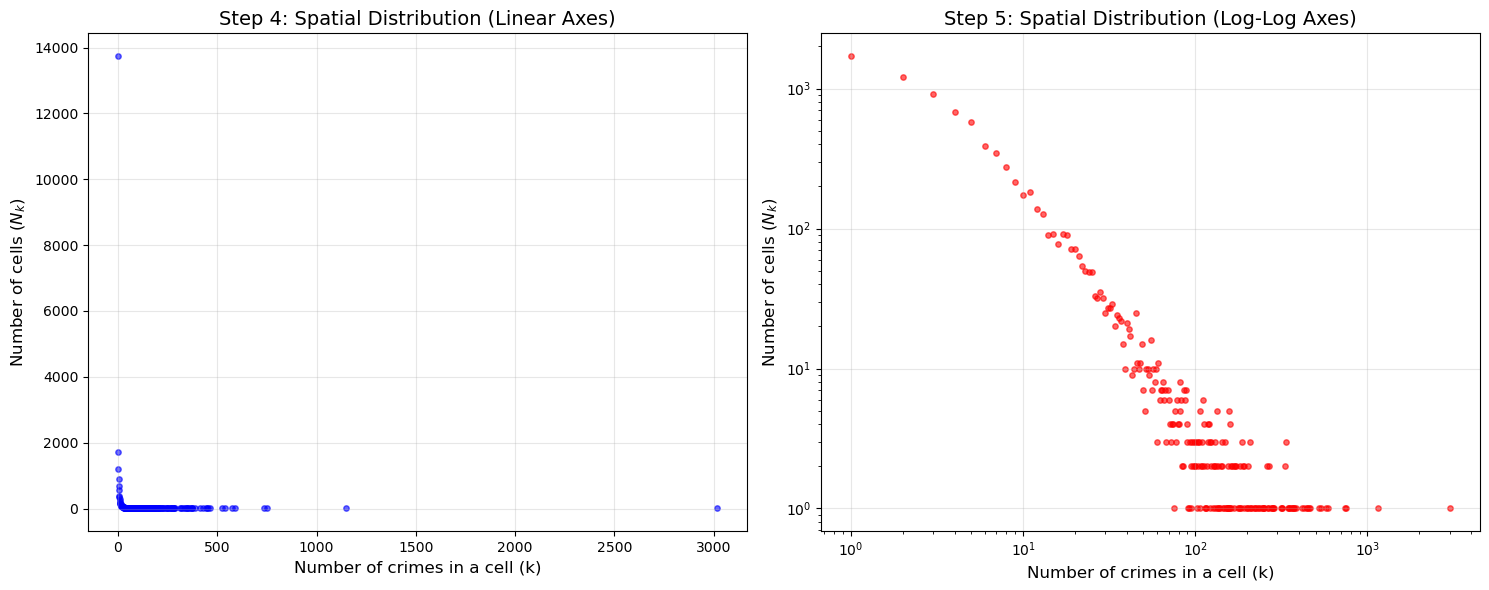

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target_crime = 'Assault'

df_spatial = df_combined[df_combined['Unified Category'].astype(str).str.strip().str.title() == target_crime].copy()

df_spatial['Latitude'] = pd.to_numeric(df_spatial['Latitude'], errors='coerce')
df_spatial['Longitude'] = pd.to_numeric(df_spatial['Longitude'], errors='coerce')
df_spatial = df_spatial.dropna(subset=['Latitude', 'Longitude'])

df_grid = df_spatial[(df_spatial['Latitude'] > 37.7) & (df_spatial['Latitude'] < 37.85) &
                     (df_spatial['Longitude'] > -122.55) & (df_spatial['Longitude'] < -122.35)]


counts, lon_edges, lat_edges = np.histogram2d(
    df_grid['Longitude'], 
    df_grid['Latitude'], 
    bins=150
)


grid_counts = counts.flatten()

k, N_k = np.unique(grid_counts, return_counts=True)

k_valid = k[k > 0]
N_k_valid = N_k[k > 0]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(k, N_k, color='blue', alpha=0.6, s=15)
ax1.set_title('Step 4: Spatial Distribution (Linear Axes)', fontsize=14)
ax1.set_xlabel('Number of crimes in a cell (k)', fontsize=12)
ax1.set_ylabel('Number of cells ($N_k$)', fontsize=12)
ax1.grid(alpha=0.3)

ax2.scatter(k_valid, N_k_valid, color='red', alpha=0.6, s=15)
ax2.set_title('Step 5: Spatial Distribution (Log-Log Axes)', fontsize=14)
ax2.set_xlabel('Number of crimes in a cell (k)', fontsize=12)
ax2.set_ylabel('Number of cells ($N_k$)', fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Step 6: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?**
Yes, it closely follows a power-law distribution. You can tell this from the log-log plot (Step 5) because the data points fall roughly along a decaying straight, diagonal line. In a log-log scale, a straight line mathematical relationship indicates a power-law. This means that a massive number of grid cells have 0 or 1 crimes (the top-left), while a very tiny fraction of cells experience a massive, disproportionate amount of crimes (the bottom-right).

**Step 7: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?**
If crime follows a power law spatially, it means crime is hyper-concentrated. It doesn't happen evenly across a neighborhood; it happens intensely at very specific hotspots (intersections, transit stops, etc.). 
Because of this extreme inequality, calculating the simple "average" or "mean" crime rate for an entire neighborhood is highly misleading. A single extreme hotspot can dramatically drag the average up for an entire neighborhood, concealing the fact that 95% of the blocks in that same neighborhood are perfectly safe. Therefore, the concept of an "average block" is not useful. For policing and city planning, it implies that resources need to be hyper-targeted to the specific micro-geography squares where the power-law dictates almost all the crime is concentrated, rather than evenly patrolling a neighborhood.


# Assignment 1.5: Regression and Correlation

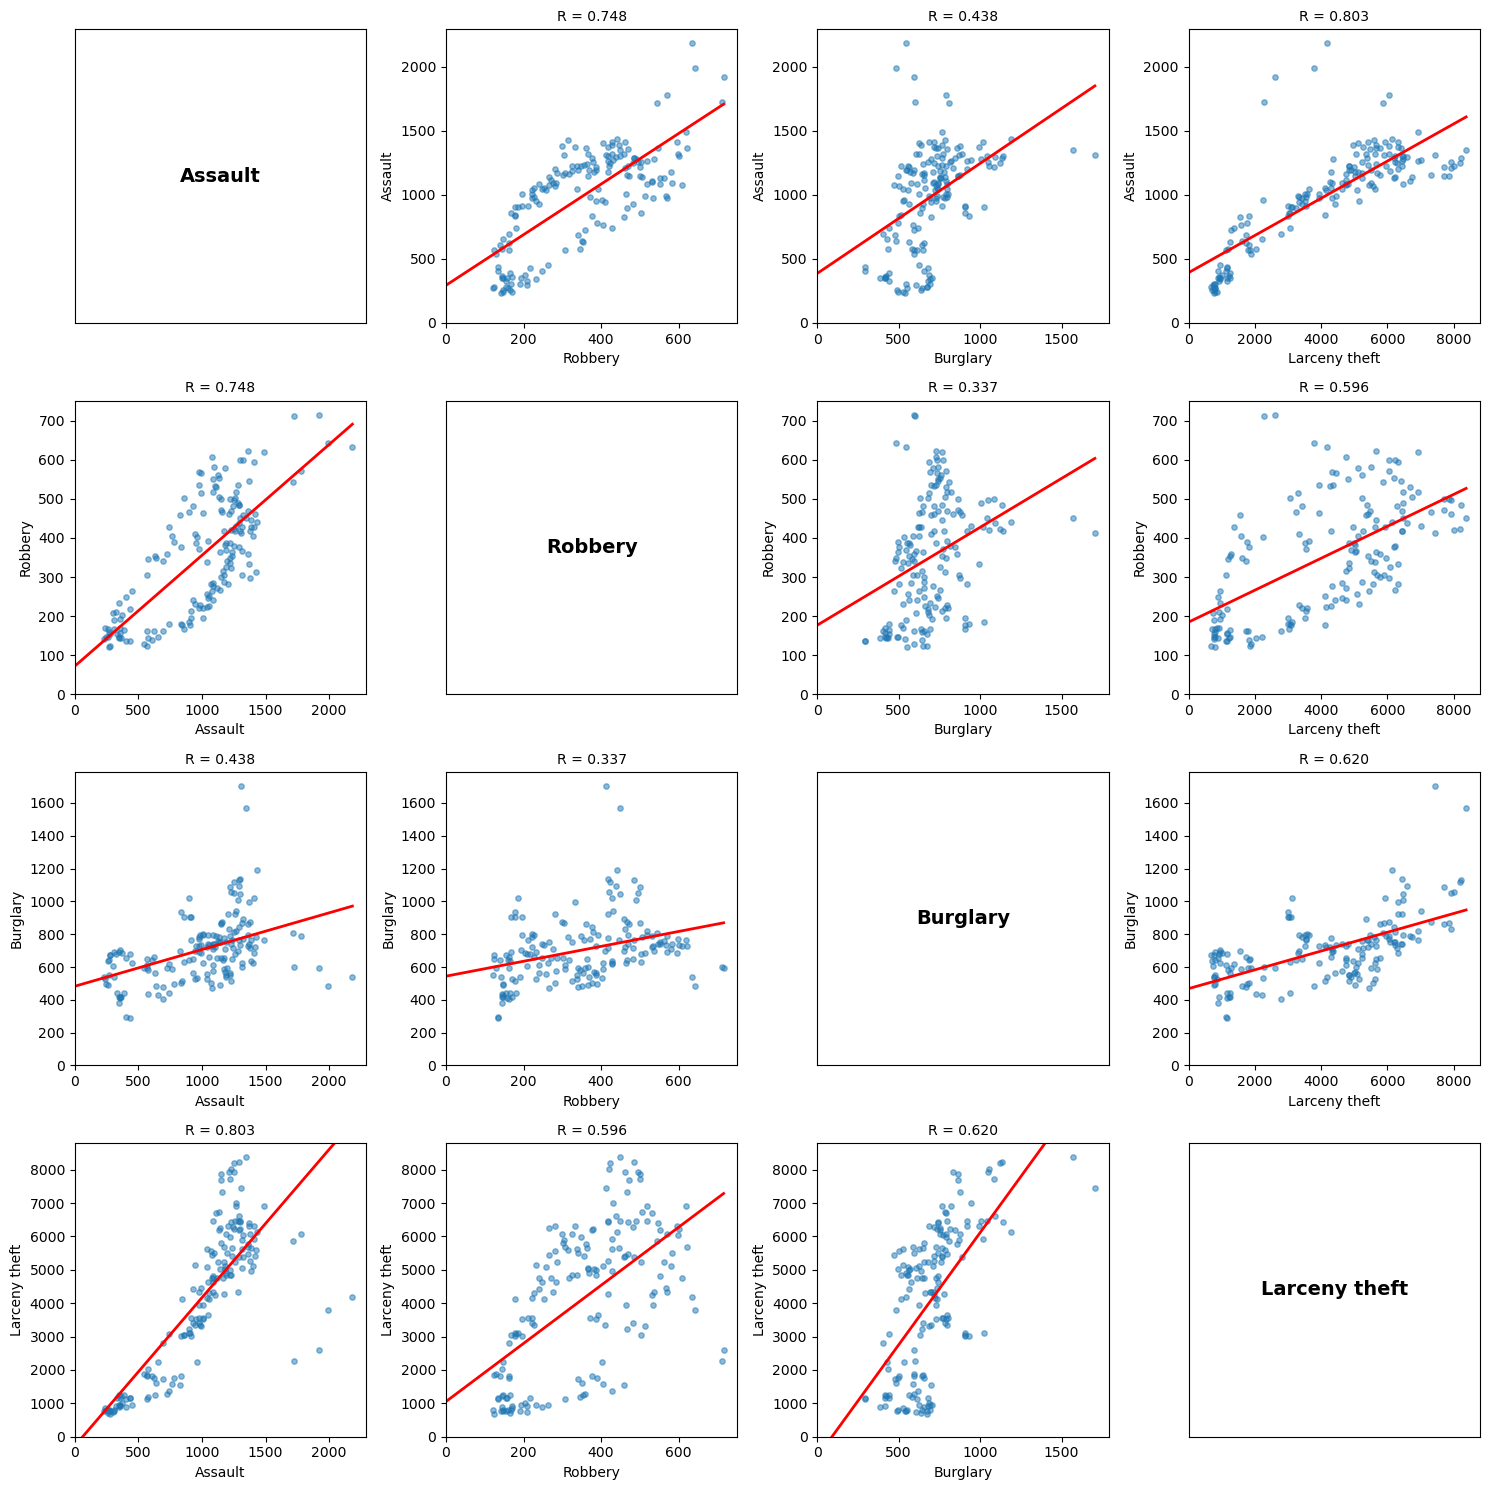

In [ ]:
df_filtered = df_combined[df_combined['Unified Category'].astype(str).str.strip().str.title().isin(['Assault', 'Robbery', 'Burglary', 'Larceny Theft'])].copy()

df_filtered['Date'] = pd.to_datetime(df_filtered['Date'], errors='coerce')
df_filtered['DayOfWeek'] = df_filtered['Date'].dt.day_name()

df_filtered['Time'] = df_filtered['Time'].astype(str)
df_filtered['Hour'] = pd.to_numeric(df_filtered['Time'].str.split(':').str[0], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Hour'])
df_filtered['Hour'] = df_filtered['Hour'].astype(int)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

crime_vectors = {}
for crime in ['Assault', 'Robbery', 'Burglary', 'Larceny Theft']:
    crime_df = df_filtered[df_filtered['Unified Category'].astype(str).str.strip().str.title() == crime]
    
    counts = crime_df.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)
    counts = counts.reindex(days_order)
    vector_168 = counts.values.flatten()
    crime_vectors[crime] = vector_168

def linear_regression(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    beta_1 = numerator / denominator
    beta_0 = y_mean - beta_1 * x_mean
    return beta_0, beta_1

def calculate_r(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
    return numerator / denominator

crimes = list(crime_vectors.keys())
n_crimes = len(crimes)

fig, axes = plt.subplots(n_crimes, n_crimes, figsize=(15, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

max_vals = {crime: np.max(crime_vectors[crime]) for crime in crimes}

for i in range(n_crimes):
    for j in range(n_crimes):
        ax = axes[i, j]
        
        if i == j:
            ax.text(0.5, 0.5, crimes[i].capitalize(), ha='center', va='center', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            x_crime = crimes[j]
            y_crime = crimes[i]
            
            x = crime_vectors[x_crime]
            y = crime_vectors[y_crime]
            
            ax.scatter(x, y, alpha=0.5, s=15)
            
            b0, b1 = linear_regression(x, y)
            r = calculate_r(x, y)
            
            x_line = np.array([0, np.max(x)])
            y_line = b0 + b1 * x_line
            ax.plot(x_line, y_line, color='red', linewidth=2)
            
            ax.set_title(f'R = {r:.3f}', fontsize=10)
            ax.set_xlabel(x_crime.capitalize())
            ax.set_ylabel(y_crime.capitalize())
            
            ax.set_xlim(0, max_vals[x_crime] * 1.05)
            ax.set_ylim(0, max_vals[y_crime] * 1.05)

plt.tight_layout()
plt.show()


**Which pair of crimes is most correlated? Which is least correlated? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?**

Looking at the generated regression matrix, the most correlated pair of crimes is **Assault** and **Larceny theft** with an R-value of **0.803**. The least correlated pair is **Robbery** and **Burglary** with an R-value of **0.337**.

This matches intuition because crimes will share a weekly rhythm when they rely on similar opportunity structures. For example, "Assault" and "Larceny theft" often peak closely together during times when public activity and street life are highest (such as weekend afternoons and evenings), increasing both the chance of interpersonal conflict and the availability of targets for theft. In contrast, "Burglary" is largely out of sync with "Robbery" because residential burglaries typically peak during weekday daytime hours when occupants are away at work, whereas robberies rely on intercepting people and thus peak when victims are out on the streets.


# CONTRIBUTION:
* Christoffer Engskov Frost (s224790): Assignment 1.2 & Assigment 1.3 (Part )
* Michelle Quynh Ngoc Mai (s224771): Assignment 1.1 & Assigment 1.3 (Part )
* Lorenzo Gelao (s253003): Assignment 1.4 & Assignment 1.5 